# CSE 579 Homework 1: Imitation Learning

In this assignment, you will implement:
1. **Behavior Cloning (BC)** with a Gaussian policy
2. **DAgger** (Dataset Aggregation)
3. **Autoregressive policy** for BC
4. **Diffusion policy** (extra credit)

You will train and evaluate on two environments: **Reacher** and **PointMaze**.

**Getting started:** Click **File > Save a copy in Drive** to create your own editable copy of this notebook. Do not edit the original.

## 1. Setup and Installation

In [1]:
# Clone the homework repository
!git clone https://github.com/WEIRDLabUW/CSE-579-HW1.git
!cp -r CSE-579-HW1/* .
!cp -r CSE-579-HW1/.gitignore .

Cloning into 'CSE-579-HW1'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 82 (delta 33), reused 67 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 30.19 MiB | 25.57 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [ ]:
# Install system dependencies (for MuJoCo rendering)
!apt-get install -y \
    libgl1-mesa-dev \
    libgl1-mesa-glx \
    libglew-dev \
    libosmesa6-dev \
    software-properties-common \
    patchelf

# Install PyTorch with CUDA support (separate to avoid index conflicts)
!pip install -q \
    torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 \
    --extra-index-url https://download.pytorch.org/whl/cu124

# Install mujoco first — latest has Python 3.12 prebuilt wheels.
# gymnasium-robotics 1.2.x pins mujoco<3.0, but those old versions lack
# cp312 wheels. We install mujoco separately, then gymnasium-robotics with
# --no-deps to avoid the downgrade, and manually install its other deps.
!pip install -q mujoco
!pip install -q "gymnasium-robotics>=1.2.0,<1.3.0" --no-deps
!pip install -q \
    gymnasium==0.29.1 \
    Jinja2 imageio PettingZoo \
    matplotlib \
    "numpy>=1.24,<2.0" \
    tqdm

import os
os.environ['LD_PRELOAD'] = ':/usr/lib/x86_64-linux-gnu/libGLEW.so'

# Restart the runtime so the new numpy version takes effect.
# After restart, skip this cell and continue from the next one.
os.kill(os.getpid(), 9)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
software-properties-common is already the newest version (0.99.22.9).
libgl1-mesa-glx is already the newest version (23.0.4-0ubuntu1~22.04.1).
The following additional packages will be installed:
  libegl-dev libgl-dev libgles-dev libgles1 libglew2.2 libglu1-mesa
  libglu1-mesa-dev libglvnd-core-dev libglvnd-dev libglx-dev libopengl-dev
  libosmesa6
Suggested packages:
  glew-utils
The following NEW packages will be installed:
  libegl-dev libgl-dev libgl1-mesa-dev libgles-dev libgles1 libglew-dev
  libglew2.2 libglu1-mesa libglu1-mesa-dev libglvnd-core-dev libglvnd-dev
  libglx-dev libopengl-dev libosmesa6 libosmesa6-dev patchelf
0 upgraded, 16 newly installed, 0 to remove and 42 not upgraded.
Need to get 4,275 kB of archives.
After this operation, 20.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libglx-dev amd64 1.4.0-1 [14.1 kB]
Get:2

**Important:** The cell above restarts the runtime to load the new numpy version. After it restarts, **do not re-run the install cell** — skip it and continue from the next cell.

In [1]:
# Re-set env var (lost after runtime restart)
import os
os.environ['LD_PRELOAD'] = ':/usr/lib/x86_64-linux-gnu/libGLEW.so'

# Verify installation — expect output: (11,)
import gymnasium as gym
env = gym.make("Reacher-v4")
print(env.reset()[0].shape)
env.close()

(11,)


## 2. Imports and Device Setup

In [2]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import math
import pickle
import matplotlib.pyplot as plt
from torch import distributions as pyd
from torch.distributions import Categorical
from torch.optim.lr_scheduler import LambdaLR
import collections
from typing import Any, Dict, Optional
from tqdm.auto import tqdm

from utils import (
    rollout, relabel_action, generate_paths, get_expert_data,
    PolicyGaussian, PolicyAutoRegressiveModel, mlp
)
from policy import (
    torchify_dict, ConditionalUnet1D, Policy, BaseDiffusionDataset,
    create_sample_indices, get_data_stats, normalize_data, unnormalize_data
)
import DiffusionPolicy as DiffusionPolicyModule
from DiffusionPolicy import DiffusionDataset
from evaluate import evaluate
import pytorch_utils as ptu
from reach_goal.envs.pointmaze_env import PointMazeEnv
from reach_goal.envs.pointmaze_expert import WaypointController

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

Using device: cuda:0


## 3. Behavior Cloning (BC)

Implement standard behavior cloning by maximizing log-likelihood of expert actions under the policy.

In [3]:
"""
TODO: MODIFY TO FILL IN YOUR BC IMPLEMENTATION
"""
def simulate_policy_bc(env, policy, expert_data, num_epochs=500, episode_length=50,
                       batch_size=32):

    # Hint: Use standard pytorch supervised learning code to train the policy.
    optimizer = optim.Adam(list(policy.parameters()), lr=1e-4)
    all_obs = np.concatenate([d['observations'] for d in expert_data]) # obs are the same as states
    all_actions = np.concatenate([d['actions'] for d in expert_data])
    num_samples = all_obs.shape[0]
    num_batches = num_samples // batch_size
    losses = []
    for epoch in range(num_epochs):
        ## TODO Students
        order = np.arange(num_samples)
        np.random.shuffle(order)
        running_loss = 0.0
        for i in range(num_batches):
            optimizer.zero_grad()
            #========== TODO: start ==========
            # Forward Pass
            start_idx = i * batch_size
            end_idx = (i + 1) * batch_size
            X_batch = torch.tensor(all_obs[start_idx:end_idx], dtype=torch.float32)
            X_batch = X_batch.to(device)

            y_batch = torch.tensor(all_actions[start_idx:end_idx], dtype=torch.float32)
            y_batch = y_batch.to(device)

            # Gives the log likelihood of experts action
            ac_log_prob = policy.log_prob(X_batch, y_batch)
            loss = -(ac_log_prob).mean()

            # Backward Pass
            #========== TODO: end ==========
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        # if epoch % 10 == 0:
        print('[%d] loss: %.8f' %
            (epoch, running_loss / num_batches))
        losses.append(loss.item())

    # Added return loss for plotting
    return losses

## 4. DAgger (Dataset Aggregation)

Implement DAgger: iteratively train a policy, roll it out, relabel the collected trajectories using the expert, and add them to the training set.

In [4]:
"""
TODO: MODIFY TO FILL IN YOUR DAGGER IMPLEMENTATION
"""
def simulate_policy_dagger(env, policy, expert_paths, expert_policy=None, num_epochs=500, episode_length=50,
                            batch_size=32, num_dagger_iters=10, num_trajs_per_dagger=10):

    # Fill in your dagger implementation here.
    # Hint: Loop through num_dagger_iters iterations, at each iteration train a policy on the current dataset.
    # Then rollout the policy, use relabel_action to relabel the actions along the trajectory
    # with "expert_policy" and then add this to current dataset.
    # Repeat this so the dataset grows with states drawn from the policy, and relabeled actions using the expert.

    # Optimizer code
    optimizer = optim.Adam(list(policy.parameters()))
    losses = []
    returns = []

    trajs = expert_paths
    # Dagger iterations
    for dagger_itr in range(num_dagger_iters):
        all_obs = np.concatenate([d['observations'] for d in trajs])
        all_actions = np.concatenate([d['actions'] for d in trajs])
        num_samples = all_obs.shape[0]
        num_batches = num_samples // batch_size
        # losses = []
        # Train the model with Adam
        for epoch in range(num_epochs):
            order = np.arange(num_samples)
            np.random.shuffle(order)
            running_loss = 0.0
            for i in range(num_batches):
                optimizer.zero_grad()
                #========== TODO: begin ==========
                # Forward Pass
                start_idx = i * batch_size
                end_idx = (i + 1) * batch_size
                sample_indices = order[start_idx:end_idx]

                X_batch = torch.tensor(all_obs[sample_indices], dtype=torch.float32)
                X_batch = X_batch.to(device)

                y_batch = torch.tensor(all_actions[sample_indices], dtype=torch.float32)
                y_batch = y_batch.to(device)

                # Gives the log likelihood of experts action
                ac_log_prob = policy.log_prob(X_batch, y_batch)
                loss = -(ac_log_prob).mean()

                # Backward Pass
                #========== TODO: end ==========
                loss.backward()
                optimizer.step()

                # print statistics
                running_loss += loss.item()
            # if epoch % 10 == 0:
            print('[%d, %5d] loss: %.8f' %(epoch + 1, i + 1, running_loss/num_batches))
            losses.append(running_loss/num_batches)

        # Collecting more data for dagger
        trajs_recent = []
        for k in range(num_trajs_per_dagger):
            env.reset()
            #========== TODO: start ==========
            # Roll out the policy along a trajectory, and add it to the data

            path = rollout(env, policy, "dagger", episode_length)
            path = relabel_action(path, expert_policy)

            # Add trajectory into the current data
            trajs_recent.append(path)
            #========== TODO: end ==========

        trajs += trajs_recent
        mean_return = np.mean(np.array([traj['rewards'].sum() for traj in trajs_recent]))
        print("Average DAgger return is " + str(mean_return))
        returns.append(mean_return)

    # Added return loss for plotting
    return losses

## 5. Autoregressive Policy

Implement the autoregressive policy that predicts each action dimension sequentially, conditioned on previous dimensions.

**Note:** In the standalone Python files, this class is defined in `utils.py`. Here we redefine it in the notebook for ease of editing.

In [5]:
"""
TODO: MODIFY TO FILL IN YOUR AUTOREGRESSIVE POLICY IMPLEMENTATION
"""
class PolicyAutoRegressiveModel(nn.Module):
    def __init__(self, num_inputs, num_outputs, hidden_dim=65, hidden_depth=2, num_buckets=10, ac_low=-1, ac_high=1):
        super(PolicyAutoRegressiveModel, self).__init__()
        self.eps = 1e-8
        self.trunks = nn.ModuleList([mlp(num_inputs, hidden_dim, num_buckets, hidden_depth)] \
                        + [mlp(num_inputs + j + 1, hidden_dim, num_buckets, hidden_depth) for j in range(num_outputs - 1)])
        self.num_dims = num_outputs
        self.ac_low = torch.tensor(ac_low).to(device)
        self.ac_high = torch.tensor(ac_high).to(device)
        self.num_buckets = num_buckets
        self.bucket_size = torch.tensor((ac_high - ac_low) / num_buckets).to(device)

    def discretize(self, ac):
        bucket_idx = (ac - self.ac_low) // (self.bucket_size + self.eps)
        return torch.clip(bucket_idx, 0, self.num_buckets - 1)

    def undiscretize(self, bucket_idx, dimension):
        return_val = bucket_idx[:, None]*self.bucket_size + self.ac_low + self.bucket_size*0.5
        return return_val[:, dimension]

    def forward(self, state):
        vals = []
        log_probs = 0
        for j in range(self.num_dims):
            #========== TODO: start ==========
            # Here, we want to predict each action on dimension at a time

            # Pass state through the respective MLP (i.e. self.trunks[j]) to get a logit
            logit = self.trunks[j](state)

            # Use the logit to create a categorical distribution (torch.Categorical)
            categorical = Categorical(logits=logit)

            # Sample from this distribution and get that sample's log probability
            ac_idx = categorical.sample()
            ac_log_prob = categorical.log_prob(ac_idx)

            # Add the log probability to the running log_probs and undiscretize the sample and append it to vals
            log_probs += ac_log_prob
            val = self.undiscretize(ac_idx, j).unsqueeze(-1)
            vals.append(val)

            # Concatenate state with previous action dimension (0, ..., j-1)
            state = torch.cat([state, val], dim=-1)

            # Important – use previous *sampled* actions
            #========== TODO: end ==========
        vals = torch.cat(vals, dim=-1)
        return vals, log_probs

    def log_prob(self, state, action):
        log_prob = 0.
        ac_discretized = self.discretize(action)
        for j in range(self.num_dims):
            #========== TODO: start ==========

            # Here, we want to get log prob of action given state under the current autoregressive model

            # Pass it through the respective MLP (i.e. self.truncks[j]) to get a logit
            logit = self.trunks[j](state)

            # Use the logit to create a categorical distribution
            categorical = Categorical(logits=logit)

            # Get the log prob of the respective discretized action (i.e., ac_discretized[:, j]) and add it to
            # the running log_prob
            ac_log_prob = categorical.log_prob(ac_discretized[:, j])
            log_prob += ac_log_prob

            # Concatenate state with all previous action dimensions (0, ..., j-1)
            cur_ac = action[:, j].unsqueeze(-1)
            state = torch.cat([state, cur_ac], dim=-1)

            # Important – use previous actions from the action variable, *not* sampled actions

            #========== TODO: end ==========

        return log_prob

## 6. Diffusion Policy (Extra Credit)

Implement the diffusion policy for the PointMaze environment.

In [6]:
# =====================================================================
# Noise scheduler
# =====================================================================
class NoiseScheduler:
    """Discrete-time DDPM noise scheduler.

    Stores beta_t, alpha_t, and alpha_bar_t, and
    implements the forward (training) and reverse (sampling) DDPM steps.
    """

    def __init__(
        self,
        num_train_timesteps: int = 100,
        beta_schedule: str = "linear",
        beta_start: float = 1e-4,
        beta_end: float = 0.02,
        device: torch.device = torch.device("cuda"),
    ):
        self.num_train_timesteps = num_train_timesteps
        self.beta_schedule = beta_schedule
        self.device = device

        # ========== TODO 1: build the beta and alpha tables ==========
        # We need three tensors of length T = num_train_timesteps:
        #   betas      : the per-step forward variances beta_t
        #   alphas     : 1 - betas
        #   alphas_bar : cumulative product of alphas, i.e. prod_{s<=t} alpha_s
        # These will be used to build a "linear" schedule: betas linearly spaced from beta_start to beta_end.

        # ========== TODO 1: end ==========

        self.betas = betas.to(device=device)
        self.alphas = alphas.to(device=device)
        self.alphas_bar = alphas_bar.to(device=device)

    def add_noise(self, x_0, noise, timesteps):
        """Forward (noising) process closed form.

        Returns x_t given x_0, the noise epsilon, and a batch of integer
        timesteps in [0, T).

        x_0       : (B, T_h, A) clean samples
        noise     : (B, T_h, A) standard normal noise of the same shape
        timesteps : (B,) integer timesteps
        """
        # ========== TODO 2: forward closed-form sample ==========
        # The DDPM forward process q(x_t | x_0) is a closed-form Gaussian:
        #   x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
        # Index into self.alphas_bar with `timesteps` to get a (B,) tensor,
        # then add singleton dims so it broadcasts against x_0.

        # ========== TODO 2: end ==========
        return x_t

    @torch.no_grad()
    def step(self, noise_pred, t, x_t):
        """One reverse DDPM step.

        Returns x_{t-1} given x_t and the predicted noise eps_theta(x_t, t).
        Uses the direct epsilon-parameterized mean from Ho et al. 2020 eq. 11
        with sigma_t^2 = beta_t.
        """
        # ========== TODO 3: reverse DDPM step ==========
        # The mean of p_theta(x_{t-1} | x_t) is (Ho et al. eq. 11):
        #
        #   mu_theta = (1 / sqrt(alpha_t)) *
        #       (x_t  -  (beta_t / sqrt(1 - alpha_bar_t)) * eps_pred)
        #
        # The variance is simply sigma_t^2 = beta_t.
        #
        # For t > 0, sample  x_{t-1} = mu_theta + sqrt(beta_t) * z,  z ~ N(0,I)
        # For t == 0, return mu_theta directly (no noise).

        # ========== TODO 3: end ==========
        return x_prev


# =====================================================================
# Cosine LR with linear warmup.
# =====================================================================
def cosine_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return LambdaLR(optimizer, lr_lambda)


# =====================================================================
# Diffusion policy
# =====================================================================
class DiffusionPolicy(Policy):
    def __init__(self, obs_size, obs_horizon, action_size, action_pred_horizon,
                 action_horizon, num_diffusion_iters=100, beta_schedule="linear",
                 device=torch.device('cuda')):
        self.device = device
        self.obs_horizon = obs_horizon
        self.action_size = action_size
        self.action_horizon = action_horizon
        self.action_pred_horizon = action_pred_horizon
        self.num_diffusion_iters = num_diffusion_iters

        self.net = ConditionalUnet1D(action_size, obs_size * obs_horizon).to(device)
        self.scheduler = NoiseScheduler(
            num_train_timesteps=num_diffusion_iters,
            beta_schedule=beta_schedule, device=device)

        self.obs_deque = collections.deque([], maxlen=self.obs_horizon)
        self.stats = None

    def set_stats(self, stats):
        self.stats = torchify_dict(stats, self.device)

    @torch.no_grad()
    def _process_obs(self, obs):
        obs = np.copy(obs)
        return {"state": torch.as_tensor(obs, dtype=torch.float32, device=self.device)}

    def reset(self):
        self.obs_deque.clear()

    def add_obs(self, obs):
        o = self._process_obs(obs)
        self.obs_deque.append(o)
        while len(self.obs_deque) < self.obs_horizon:
            self.obs_deque.append(o)

    def __call__(self, obs=None):
        return self.get_action(obs.squeeze() if obs is not None else None)

    @torch.no_grad()
    def get_action(self, obs=None):
        assert self.stats is not None
        if obs is not None:
            self.add_obs(obs)
        assert len(self.obs_deque) == self.obs_horizon
        states = torch.stack([x["state"] for x in self.obs_deque])

        # ========== TODO 5: sampling loop ==========
        # 1. Normalize the observation history with self.stats['state'] and
        #    flatten it to a (1, obs_horizon * obs_dim) conditioning tensor
        #    that the UNet expects via its `global_cond` argument.
        #
        # 2. Initialize a tensor of pure Gaussian noise with shape
        #    (1, action_pred_horizon, action_size). This is x_K, the most
        #    noised "action" we will progressively denoise.
        #
        # 3. Loop t = num_diffusion_iters - 1, ..., 0:
        #       a. Predict the noise: eps_pred = self.net(naction, t, obs_cond)
        #       b. Step:               naction = self.scheduler.step(
        #                                            eps_pred, t, naction)
        #
        # 4. Drop the batch dimension and unnormalize with
        #    self.stats['action'] to recover real-valued actions.
        #
        # 5. Slice out the action_horizon actions starting from index
        #    obs_horizon - 1 -- this is the "action chunk" we will execute
        #    before re-querying the policy.

        # ========== TODO 5: end ==========
        return action, {}

    def state_dict(self):
        return dict(net=self.net.state_dict(), stats=self.stats)

    def load_state_dict(self, state_dict):
        self.net.load_state_dict(state_dict["net"])
        self.set_stats(state_dict["stats"])


def train_diffusion_policy(policy, expert_data, num_epochs=500, batch_size=32):
    dataset = DiffusionDataset(expert_data, pred_horizon=policy.action_pred_horizon,
                               obs_horizon=policy.obs_horizon, action_horizon=policy.action_horizon)
    policy.set_stats(dataset.stats)

    data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True,
        num_workers=4, pin_memory=True, persistent_workers=True)

    optimizer = torch.optim.AdamW(policy.net.parameters(), lr=1e-4, weight_decay=1e-6)
    num_training_steps = len(data_loader) * num_epochs
    lr_scheduler = cosine_with_warmup(
        optimizer, num_warmup_steps=num_training_steps // 10,
        num_training_steps=num_training_steps)

    losses = []
    for epoch in tqdm(range(num_epochs)):
        running_loss = 0.0
        with tqdm(data_loader, leave=False) as tepoch:
            for batch in tepoch:
                naction = batch['action'].to(policy.device)
                nstate = batch['state'][:, :policy.obs_horizon].to(policy.device)
                B = nstate.shape[0]

                # ========== TODO 4: training step ==========
                # 1. Flatten the observation history into the global
                #    conditioning vector the UNet expects:
                #        obs_cond shape (B, obs_horizon * obs_dim)
                #
                # 2. Sample standard normal noise of the same shape as
                #    naction.
                #
                # 3. Sample one diffusion timestep per element of the batch:
                #        timesteps ~ Uniform{0, ..., T-1}, shape (B,)
                #
                # 4. Build the noisy actions x_t with the scheduler:
                #        noisy = policy.scheduler.add_noise(
                #            naction, noise, timesteps)
                #
                # 5. Predict the noise residual:
                #        noise_pred = policy.net(noisy, timesteps, obs_cond)
                #
                # 6. Compute MSE loss between predicted and true noise.

                # ========== TODO 4: end ==========

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                lr_scheduler.step()

                loss_cpu = loss.item()
                running_loss += loss_cpu
                tepoch.set_postfix(loss=loss_cpu)
        epoch_loss = running_loss / len(data_loader)
        losses.append(epoch_loss)
        print(f"epoch {epoch} loss: {epoch_loss:.6f}")

    return policy

---
## 7. Training and Evaluation

Below we define helper functions and then run all the required training configurations.

In [7]:
class Args:
    def __init__(self, env, train, policy, test=False, render=False):
        self.env = env       # 'reacher' or 'pointmaze'
        self.train = train   # 'behavior_cloning' or 'dagger' or 'diffusion'
        self.policy = policy # 'gaussian' or 'autoregressive' or 'diffusion'
        self.test = test
        self.render = render


# def evaluate(env, policy, agent_name, num_validation_runs=10, episode_length=50, render=False, env_name=None):
#     success_count = 0
#     rewards_suc = 0
#     rewards_all = 0
#     for k in range(num_validation_runs):
#         o, _ = env.reset()
#         if agent_name == 'diffusion':
#             policy.reset()
#         path = rollout(
#                 env,
#                 policy,
#                 agent_name=agent_name,
#                 episode_length=episode_length,
#                 render=render)
#         if agent_name == 'pg':
#             success = len(path['dones']) == episode_length
#         elif agent_name == 'behavior_cloning' or agent_name == "diffusion" or agent_name == 'dagger':
#             if env_name == 'reacher':
#                 success = np.linalg.norm(env.unwrapped.get_body_com("fingertip") - env.unwrapped.get_body_com("target"))<0.1
#             elif env_name == 'pointmaze':
#                 success = sum(path['dones']) > 0
#             else:
#                 raise ValueError('Invalid environment')
#         else:
#             raise ValueError('Invalid agent name')
#         if success:
#             success_count += 1
#             rewards_suc += np.sum(path['rewards'])
#         rewards_all += np.sum(path['rewards'])
#         print(f"test {k}, success {success}, reward {np.sum(path['rewards'])}")
#     print("Success rate: ", success_count/num_validation_runs)
#     # print("Average reward (success only): ", rewards_suc/max(success_count, 1))
#     # print("Average reward (all): ", rewards_all/num_validation_runs)
#     return success_count/num_validation_runs, rewards_suc/max(success_count, 1), rewards_all/num_validation_runs

# def setup_and_run(args):
#     """Load data, create env/policy, train, evaluate, and save weights."""
#     # Get expert data
#     if args.env == 'reacher':
#         file_path = 'data/reacher_expert_data.pkl'
#     elif args.env == 'pointmaze':
#         file_path = 'data/pointmaze_expert_data.pkl'
#     else:
#         raise ValueError('Invalid environment')
#     expert_data = get_expert_data(file_path)

#     flattened_expert = {'observations': [], 'actions': []}
#     for expert_path in expert_data:
#         for k in flattened_expert.keys():
#             flattened_expert[k].append(expert_path[k])
#     for k in flattened_expert.keys():
#         flattened_expert[k] = np.concatenate(flattened_expert[k])

#     # Define environment
#     if args.env == 'reacher':
#         env = gym.make("Reacher-v4", render_mode='human' if args.render else None)
#     elif args.env == 'pointmaze':
#         env = PointMazeEnv(render_mode='human' if args.render else 'rgb_array')

#     # Define policy
#     hidden_dim = 128
#     hidden_depth = 2
#     obs_size = env.observation_space.shape[0]
#     ac_size = env.action_space.shape[0]
#     ac_margin = 0.1

#     if args.policy == 'gaussian':
#         policy = PolicyGaussian(num_inputs=obs_size, num_outputs=ac_size, hidden_dim=hidden_dim, hidden_depth=hidden_depth)
#         policy.to(device)
#     elif args.policy == 'autoregressive':
#         num_buckets = 10
#         policy = PolicyAutoRegressiveModel(num_inputs=obs_size, num_outputs=ac_size, hidden_dim=hidden_dim,
#                                             hidden_depth=hidden_depth, num_buckets=num_buckets,
#                                             ac_low=flattened_expert['actions'].min(axis=0) - ac_margin,
#                                             ac_high=flattened_expert['actions'].max(axis=0) + ac_margin)
#         policy.to(device)
#     elif args.policy == 'diffusion':
#         policy = DiffusionPolicy(obs_size=obs_size, obs_horizon=4, action_size=ac_size,
#                                  action_horizon=8, action_pred_horizon=12,
#                                  num_diffusion_iters=100, device=device)

#     # Training hyperparameters
#     if args.env == 'reacher':
#         episode_length = 50
#         num_epochs = 500
#         batches = [1, 2, 4, 8, 16, 32, 64, 128]
#         batch_size = 32
#     elif args.env == 'pointmaze':
#         episode_length = 300
#         num_epochs = 10
#         batch_size = 128
#         if args.train == 'diffusion':
#             num_epochs = 1

#     if not args.test:
#         if args.train == 'behavior_cloning':
#             rates = []
#             for batch_size in batches:
#               print(f"Batch Size: {batch_size}")
#               losses = simulate_policy_bc(env, policy, expert_data, num_epochs=num_epochs,
#                                 episode_length=episode_length, batch_size=batch_size)
#               sr, avg_reward_succ, avg_reward = evaluate(env, policy, args.train, num_validation_runs=100, episode_length=episode_length,
#              render=args.render, env_name=args.env)
#               rates.append(sr)

#             # Plot the Success Rate vs. Batch Size
#             x = batches
#             y = rates

#             plt.plot(x, y)
#             plt.title(f"Success Rate vs. Batch Size via Behavior Cloning for {args.env.capitalize()}")
#             plt.xlabel("Batch Size")
#             plt.ylabel("Success Rate")

#             plt.show()
#         elif args.train == 'dagger':
#             if args.env == 'reacher':
#                 expert_policy = torch.load('data/reacher_expert_policy.pkl', map_location=torch.device(device), weights_only=False)
#                 print("Expert policy loaded")
#                 expert_policy.to(device)
#                 ptu.set_gpu_mode(torch.cuda.is_available())
#             elif args.env == 'pointmaze':
#                 expert_policy = WaypointController(env.maze)

#             num_dagger_iters = 10
#             num_epochs = int(num_epochs / num_dagger_iters)
#             # trajs_per_dagger = [0, 5, 10, 20, 50]
#             trajs_per_dagger = [0, 5, 10, 20, 50]
#             rates = []
#             for num_trajs_per_dagger in trajs_per_dagger:
#               print(f"Number of Trajectories per DAgger: {num_trajs_per_dagger}")
#               losses = simulate_policy_dagger(env, policy, expert_data, expert_policy,
#                                     num_epochs=num_epochs, episode_length=episode_length,
#                                     batch_size=batch_size, num_dagger_iters=num_dagger_iters,
#                                     num_trajs_per_dagger=num_trajs_per_dagger)
#               sr, avg_reward_succ, avg_reward = evaluate(env, policy, args.train, num_validation_runs=100, episode_length=episode_length,
#              render=args.render, env_name=args.env)
#               rates.append(sr)

#             # Plot the Success Rate vs. Number of Trajectories per DAgger
#             x = trajs_per_dagger
#             y = rates

#             plt.plot(x, y)
#             plt.title(f"Success Rate vs. Num Trajectories per DAgger for {args.env.capitalize()}")
#             plt.xlabel("Number of Trajectories per DAgger")
#             plt.ylabel("Success Rate")

#             plt.show()
#         elif args.train == 'diffusion' and args.env == 'pointmaze':
#             policy = train_diffusion_policy(policy, get_expert_data(file_path),
#                                            num_epochs=num_epochs, batch_size=batch_size)
#         else:
#             raise ValueError('Invalid training method')

#         torch.save(policy.state_dict(), f'{args.policy}_{args.env}_{args.train}_final.pth')
#     else:
#         policy.load_state_dict(torch.load(f'{args.policy}_{args.env}_{args.train}_final.pth', weights_only=True))

#     evaluate(env, policy, args.train, num_validation_runs=100, episode_length=episode_length,
#              render=args.render, env_name=args.env)
#     env.close()
#     return policy

def setup_and_run(args):
    """Load data, create env/policy, train, evaluate, and save weights."""
    # Get expert data
    if args.env == 'reacher':
        file_path = 'data/reacher_expert_data.pkl'
    elif args.env == 'pointmaze':
        file_path = 'data/pointmaze_expert_data.pkl'
    else:
        raise ValueError('Invalid environment')
    expert_data = get_expert_data(file_path)

    flattened_expert = {'observations': [], 'actions': []}
    for expert_path in expert_data:
        for k in flattened_expert.keys():
            flattened_expert[k].append(expert_path[k])
    for k in flattened_expert.keys():
        flattened_expert[k] = np.concatenate(flattened_expert[k])

    # Define environment
    if args.env == 'reacher':
        env = gym.make("Reacher-v4", render_mode='human' if args.render else None)
    elif args.env == 'pointmaze':
        env = PointMazeEnv(render_mode='human' if args.render else 'rgb_array')

    # Define policy
    hidden_dim = 128
    hidden_depth = 2
    obs_size = env.observation_space.shape[0]
    ac_size = env.action_space.shape[0]
    ac_margin = 0.1

    if args.policy == 'gaussian':
        policy = PolicyGaussian(num_inputs=obs_size, num_outputs=ac_size, hidden_dim=hidden_dim, hidden_depth=hidden_depth)
        policy.to(device)
    elif args.policy == 'autoregressive':
        num_buckets = 10
        policy = PolicyAutoRegressiveModel(num_inputs=obs_size, num_outputs=ac_size, hidden_dim=hidden_dim,
                                            hidden_depth=hidden_depth, num_buckets=num_buckets,
                                            ac_low=flattened_expert['actions'].min(axis=0) - ac_margin,
                                            ac_high=flattened_expert['actions'].max(axis=0) + ac_margin)
        policy.to(device)
    elif args.policy == 'diffusion':
        policy = DiffusionPolicy(obs_size=obs_size, obs_horizon=4, action_size=ac_size,
                                 action_horizon=8, action_pred_horizon=12,
                                 num_diffusion_iters=100, device=device)

    # Training hyperparameters
    if args.env == 'reacher':
        episode_length = 50
        num_epochs = 500
        batch_size = 32
    elif args.env == 'pointmaze':
        episode_length = 300
        num_epochs = 10
        batch_size = 128
        if args.train == 'diffusion':
            num_epochs = 1

    if not args.test:
        if args.train == 'behavior_cloning':
            losses = simulate_policy_bc(env, policy, expert_data, num_epochs=num_epochs,
                               episode_length=episode_length, batch_size=batch_size)
            # Plot the losses
            x = list(range(1, len(losses) + 1))
            y = losses

            plt.plot(x, y)
            if args.policy == 'autoregressive':
              plt.title(f"Autoregressive Behavior Cloning Loss during Training for {args.env.capitalize()}")
            else:
              plt.title(f"Behavior Cloning Loss during Training for {args.env.capitalize()}")
            plt.xlabel("Epochs")
            plt.ylabel("Loss")

            plt.show()
        elif args.train == 'dagger':
            if args.env == 'reacher':
                expert_policy = torch.load('data/reacher_expert_policy.pkl', map_location=torch.device(device), weights_only=False)
                print("Expert policy loaded")
                expert_policy.to(device)
                ptu.set_gpu_mode(torch.cuda.is_available())
            elif args.env == 'pointmaze':
                expert_policy = WaypointController(env.maze)

            num_dagger_iters = 10
            num_epochs = int(num_epochs / num_dagger_iters)
            num_trajs_per_dagger = 10

            losses = simulate_policy_dagger(env, policy, expert_data, expert_policy,
                                   num_epochs=num_epochs, episode_length=episode_length,
                                   batch_size=batch_size, num_dagger_iters=num_dagger_iters,
                                   num_trajs_per_dagger=num_trajs_per_dagger)
            print("Losses")
            print(losses)

            # Plot the losses
            x = list(range(1, len(losses) + 1))
            y = losses

            plt.plot(x, y)
            plt.title(f"DAgger Loss during Training for {args.env.capitalize()}")
            plt.xlabel("DAgger Iterations")
            plt.ylabel("Loss")

            plt.show()
        elif args.train == 'diffusion' and args.env == 'pointmaze':
            policy = train_diffusion_policy(policy, get_expert_data(file_path),
                                           num_epochs=num_epochs, batch_size=batch_size)
        else:
            raise ValueError('Invalid training method')

        torch.save(policy.state_dict(), f'{args.policy}_{args.env}_{args.train}_final.pth')
    else:
        policy.load_state_dict(torch.load(f'{args.policy}_{args.env}_{args.train}_final.pth', weights_only=True))

    evaluate(env, policy, args.train, num_validation_runs=100, episode_length=episode_length,
             render=args.render, env_name=args.env)
    env.close()
    return policy

### 7a. Gaussian BC — Reacher

Imported Expert data successfully
[0] loss: 1.82674709
[1] loss: 1.76177398
[2] loss: 1.69736406
[3] loss: 1.63215467
[4] loss: 1.56485260
[5] loss: 1.49413705
[6] loss: 1.41885900
[7] loss: 1.33830869
[8] loss: 1.25196253
[9] loss: 1.15951777
[10] loss: 1.06052113
[11] loss: 0.95449202
[12] loss: 0.84069662
[13] loss: 0.71790715
[14] loss: 0.58625604
[15] loss: 0.44662623
[16] loss: 0.29955467
[17] loss: 0.14569420
[18] loss: -0.01459463
[19] loss: -0.18018060
[20] loss: -0.34716135
[21] loss: -0.48483167
[22] loss: -0.55712187
[23] loss: -0.74140782
[24] loss: -0.90277368
[25] loss: -0.99129999
[26] loss: -0.88845858
[27] loss: -0.80586941
[28] loss: -1.20764514
[29] loss: -1.18531818
[30] loss: -1.35353122
[31] loss: -1.41243342
[32] loss: -1.49099744
[33] loss: -1.53189480
[34] loss: -1.51504487
[35] loss: -1.28516405
[36] loss: -1.22850348
[37] loss: -1.62689692
[38] loss: -1.57128443
[39] loss: -1.54040617
[40] loss: -1.58505883
[41] loss: -1.69735437
[42] loss: -1.83514595
[43] 

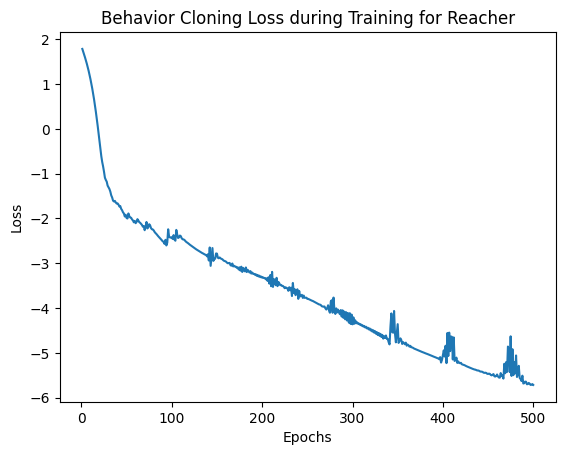

test 0, success False, reward -16.06379879451748
test 1, success False, reward -10.52091222487734
test 2, success False, reward -11.743627396365879
test 3, success False, reward -17.220484654249613
test 4, success False, reward -22.74354339701106
test 5, success True, reward -2.6719267505709636
test 6, success False, reward -14.21375677183193
test 7, success False, reward -8.062219717422796
test 8, success False, reward -20.275309785294294
test 9, success False, reward -11.171564315281318
test 10, success True, reward -17.33065531738937
test 11, success False, reward -8.847106474657702
test 12, success True, reward -8.603334352118647
test 13, success True, reward -14.120297446608285
test 14, success False, reward -22.11696018765452
test 15, success False, reward -21.499070721411783
test 16, success True, reward -8.852893857595275
test 17, success True, reward -6.370763042760742
test 18, success False, reward -13.902133401242729
test 19, success True, reward -1.4223347013339673
test 20,

In [8]:
args = Args('reacher', 'behavior_cloning', 'gaussian')
policy_gaussian_reacher_bc = setup_and_run(args)

### 7b. Gaussian DAgger — Reacher

Imported Expert data successfully
Expert policy loaded
[1,     7] loss: 1.81636081
[2,     7] loss: 0.97010955
[3,     7] loss: -0.14305881
[4,     7] loss: -0.14585747
[5,     7] loss: -0.50155837
[6,     7] loss: -0.54369596
[7,     7] loss: -0.79083016
[8,     7] loss: -1.05331922
[9,     7] loss: -1.43781781
[10,     7] loss: -1.92592081
[11,     7] loss: -2.22722881
[12,     7] loss: -2.51759846
[13,     7] loss: -2.60166321
[14,     7] loss: -2.21681804
[15,     7] loss: -2.57257353
[16,     7] loss: -2.85499232
[17,     7] loss: -3.22595392
[18,     7] loss: -3.49133130
[19,     7] loss: -3.57424784
[20,     7] loss: -3.81773887
[21,     7] loss: -4.27714562
[22,     7] loss: -4.38387918
[23,     7] loss: -4.51278864
[24,     7] loss: -3.90473189
[25,     7] loss: -4.12828950
[26,     7] loss: -4.49535155
[27,     7] loss: -4.13812576
[28,     7] loss: -4.20118686
[29,     7] loss: -4.48689726
[30,     7] loss: -4.82106420
[31,     7] loss: -5.01172679
[32,     7] loss: -4.95050

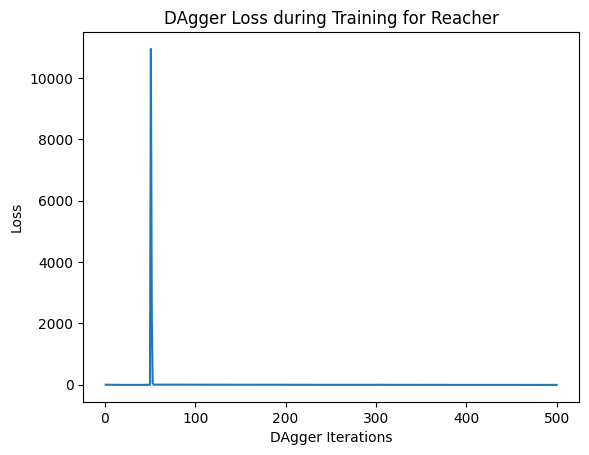

test 0, success True, reward -4.35396516615076
test 1, success True, reward -6.018888578774451
test 2, success True, reward -2.820631153209026
test 3, success True, reward -3.7747767687778344
test 4, success True, reward -5.868431313633853
test 5, success True, reward -1.602649840432629
test 6, success True, reward -3.713494041314528
test 7, success True, reward -2.43300498780342
test 8, success True, reward -2.9289984747757756
test 9, success True, reward -5.3388168565228575
test 10, success True, reward -3.4107338725078424
test 11, success True, reward -4.88855104778423
test 12, success True, reward -2.6646181038902275
test 13, success True, reward -3.480845868530767
test 14, success True, reward -1.1876664653994184
test 15, success True, reward -4.5072366713369325
test 16, success True, reward -6.095370556476675
test 17, success True, reward -3.103838258383064
test 18, success True, reward -3.6675004426925875
test 19, success True, reward -8.408596357757885
test 20, success True, re

In [9]:
args = Args('reacher', 'dagger', 'gaussian')
policy_gaussian_reacher_dagger = setup_and_run(args)

### 7c. Gaussian BC — PointMaze

Imported Expert data successfully
[0] loss: 0.55251906
[1] loss: -0.46863180
[2] loss: -0.92576518
[3] loss: -1.19565928
[4] loss: -1.38448659
[5] loss: -1.54756963
[6] loss: -1.68588286
[7] loss: -1.80820308
[8] loss: -1.91095866
[9] loss: -2.00385942


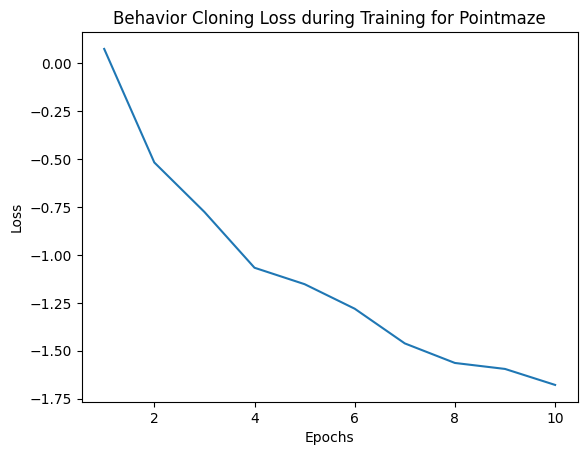

test 0, success [False], reward 0.0
test 1, success [ True], reward 1.0
test 2, success [False], reward 0.0
test 3, success [False], reward 0.0
test 4, success [False], reward 0.0
test 5, success [ True], reward 1.0
test 6, success [ True], reward 1.0
test 7, success [False], reward 0.0
test 8, success [False], reward 0.0
test 9, success [False], reward 0.0
test 10, success [ True], reward 1.0
test 11, success [False], reward 0.0
test 12, success [False], reward 0.0
test 13, success [False], reward 0.0
test 14, success [False], reward 0.0
test 15, success [False], reward 0.0
test 16, success [False], reward 0.0
test 17, success [False], reward 0.0
test 18, success [False], reward 0.0
test 19, success [False], reward 0.0
test 20, success [ True], reward 1.0
test 21, success [False], reward 0.0
test 22, success [False], reward 0.0
test 23, success [False], reward 0.0
test 24, success [False], reward 0.0
test 25, success [False], reward 0.0
test 26, success [ True], reward 1.0
test 27, su

In [10]:
args = Args('pointmaze', 'behavior_cloning', 'gaussian')
policy_gaussian_pointmaze_bc = setup_and_run(args)

### 7d. Gaussian DAgger — PointMaze

Imported Expert data successfully
[1,  7355] loss: -1.58126128
Average DAgger return is 0.4
[1,  7377] loss: -1.49070504
Average DAgger return is 0.7
[1,  7399] loss: -1.97082289
Average DAgger return is 0.7
[1,  7419] loss: -1.70519043
Average DAgger return is 1.0
[1,  7437] loss: -1.96407568
Average DAgger return is 0.4
[1,  7458] loss: -2.06797477
Average DAgger return is 0.9
[1,  7474] loss: -2.13903234
Average DAgger return is 1.0
[1,  7491] loss: -2.14992075
Average DAgger return is 1.0
[1,  7507] loss: -2.18827156
Average DAgger return is 0.9
[1,  7524] loss: -2.13881772
Average DAgger return is 0.5
Losses
[-1.5812612757613511, -1.4907050358273681, -1.970822894187743, -1.7051904284845811, -1.9640756834734667, -2.067974765591981, -2.1390323376421114, -2.149920750258682, -2.1882715592230544, -2.13881771618838]


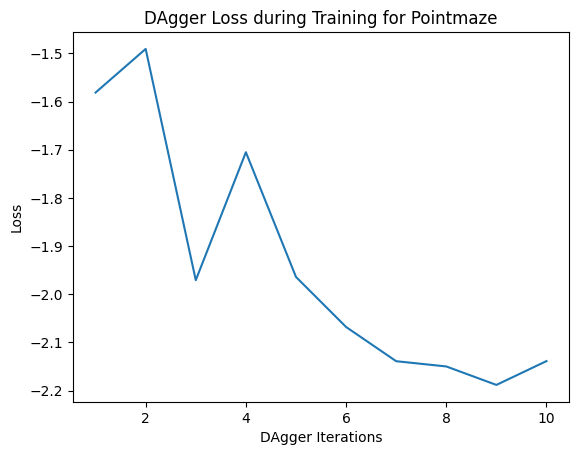

test 0, success [False], reward 0.0
test 1, success [ True], reward 1.0
test 2, success [ True], reward 1.0
test 3, success [False], reward 0.0
test 4, success [False], reward 0.0
test 5, success [False], reward 0.0
test 6, success [False], reward 0.0
test 7, success [ True], reward 1.0
test 8, success [False], reward 0.0
test 9, success [ True], reward 1.0
test 10, success [ True], reward 1.0
test 11, success [ True], reward 1.0
test 12, success [False], reward 0.0
test 13, success [ True], reward 1.0
test 14, success [ True], reward 1.0
test 15, success [False], reward 0.0
test 16, success [ True], reward 1.0
test 17, success [False], reward 0.0
test 18, success [False], reward 0.0
test 19, success [ True], reward 1.0
test 20, success [False], reward 0.0
test 21, success [False], reward 0.0
test 22, success [ True], reward 1.0
test 23, success [ True], reward 1.0
test 24, success [False], reward 0.0
test 25, success [ True], reward 1.0
test 26, success [ True], reward 1.0
test 27, su

In [11]:
args = Args('pointmaze', 'dagger', 'gaussian')
policy_gaussian_pointmaze_dagger = setup_and_run(args)

### 7e. Autoregressive BC — Reacher

Imported Expert data successfully
[0] loss: 4.55619117
[1] loss: 4.49540268
[2] loss: 4.43652650
[3] loss: 4.37799672
[4] loss: 4.31902054
[5] loss: 4.25889369
[6] loss: 4.19752829
[7] loss: 4.13459199
[8] loss: 4.06961461
[9] loss: 4.00264856
[10] loss: 3.93396541
[11] loss: 3.86400424
[12] loss: 3.79299164
[13] loss: 3.72086157
[14] loss: 3.64802275
[15] loss: 3.57471248
[16] loss: 3.50136474
[17] loss: 3.42838124
[18] loss: 3.35610815
[19] loss: 3.28479239
[20] loss: 3.21468823
[21] loss: 3.14613812
[22] loss: 3.07950129
[23] loss: 3.01495654
[24] loss: 2.95249009
[25] loss: 2.89208565
[26] loss: 2.83373543
[27] loss: 2.77774695
[28] loss: 2.72414827
[29] loss: 2.67287043
[30] loss: 2.62392729
[31] loss: 2.57721288
[32] loss: 2.53268491
[33] loss: 2.49022707
[34] loss: 2.44976509
[35] loss: 2.41122607
[36] loss: 2.37450850
[37] loss: 2.33947338
[38] loss: 2.30601375
[39] loss: 2.27402561
[40] loss: 2.24336413
[41] loss: 2.21397901
[42] loss: 2.18574476
[43] loss: 2.15859309
[44] los

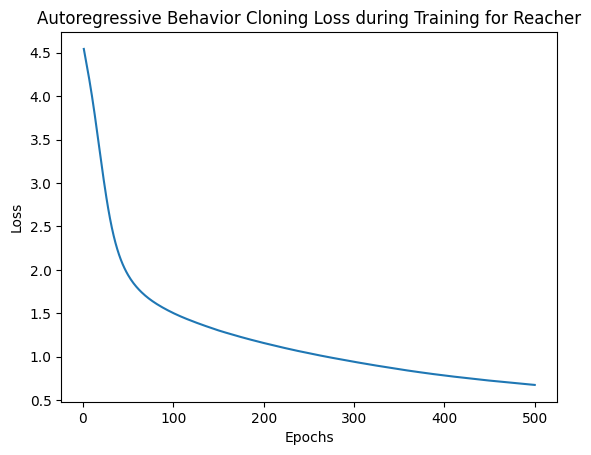

test 0, success False, reward -5.868257354513483
test 1, success False, reward -7.715914418219176
test 2, success False, reward -15.561799248903283
test 3, success False, reward -15.130156239742167
test 4, success False, reward -6.93176889729484
test 5, success True, reward -11.587181784179197
test 6, success True, reward -7.898557294914243
test 7, success False, reward -12.081501367945549
test 8, success True, reward -6.47731830182357
test 9, success False, reward -9.191423684158222
test 10, success False, reward -7.404090468631897
test 11, success True, reward -6.134219496833484
test 12, success False, reward -14.587310792960421
test 13, success True, reward -12.073576088953551
test 14, success False, reward -14.59203569099046
test 15, success False, reward -12.613842093902102
test 16, success False, reward -11.620438761936265
test 17, success False, reward -10.689683888955921
test 18, success False, reward -10.698035041200159
test 19, success False, reward -11.300204188094336
test 2

In [12]:
args = Args('reacher', 'behavior_cloning', 'autoregressive')
policy_autoregressive_reacher_bc = setup_and_run(args)

### 7f. Autoregressive BC — PointMaze

Imported Expert data successfully
[0] loss: 1.85287596
[1] loss: 1.33081871
[2] loss: 1.14659489
[3] loss: 1.03243765
[4] loss: 0.95362275
[5] loss: 0.89589659
[6] loss: 0.85132059
[7] loss: 0.81607230
[8] loss: 0.78767226
[9] loss: 0.76424273


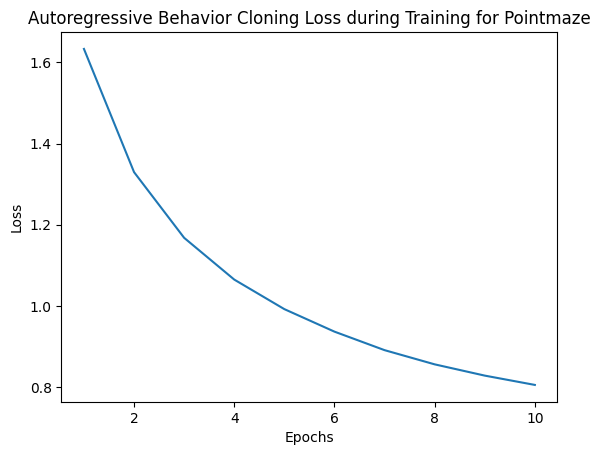

test 0, success [ True], reward 1.0
test 1, success [ True], reward 1.0
test 2, success [ True], reward 1.0
test 3, success [ True], reward 1.0
test 4, success [ True], reward 1.0
test 5, success [ True], reward 1.0
test 6, success [ True], reward 1.0
test 7, success [ True], reward 1.0
test 8, success [ True], reward 1.0
test 9, success [ True], reward 1.0
test 10, success [ True], reward 1.0
test 11, success [ True], reward 1.0
test 12, success [ True], reward 1.0
test 13, success [False], reward 0.0
test 14, success [False], reward 0.0
test 15, success [ True], reward 1.0
test 16, success [ True], reward 1.0
test 17, success [ True], reward 1.0
test 18, success [ True], reward 1.0
test 19, success [ True], reward 1.0
test 20, success [ True], reward 1.0
test 21, success [ True], reward 1.0
test 22, success [ True], reward 1.0
test 23, success [ True], reward 1.0
test 24, success [False], reward 0.0
test 25, success [ True], reward 1.0
test 26, success [False], reward 0.0
test 27, su

In [13]:
args = Args('pointmaze', 'behavior_cloning', 'autoregressive')
policy_autoregressive_pointmaze_bc = setup_and_run(args)

### 7g. Diffusion Policy — PointMaze (Extra Credit)

In [14]:
args = Args('pointmaze', 'diffusion', 'diffusion')
policy_diffusion_pointmaze = setup_and_run(args)

Imported Expert data successfully
number of parameters: 6.543923e+07


NameError: name 'betas' is not defined

---
## 8. Submit to Autograder

After training all configurations, submit your code and weight files to Gradescope.

**If you worked in Colab:** Go to **File > Download > Download .py**, then upload that `.py` file along with your `.pth` weight files to the autograder. The autograder will automatically extract your code from the exported file.

**If you worked locally:** Submit `bc.py`, `dagger.py`, `utils.py`, `DiffusionPolicy.py`, and your `.pth` weight files.

Run the cell below to collect all weight files for download.

In [15]:
import glob
import shutil

# List all saved weight files
weight_files = glob.glob('*_final.pth')
print("Found weight files:")
for f in sorted(weight_files):
    print(f"  {f}")

# Create a zip archive of weight files for easy download
submission_dir = 'submission'
os.makedirs(submission_dir, exist_ok=True)

for f in weight_files:
    shutil.copy(f, os.path.join(submission_dir, f))

shutil.make_archive('submission', 'zip', submission_dir)
print(f"\nCreated submission.zip with {len(weight_files)} weight files.")
print("\nTo submit to Gradescope:")
print("  1. Download this notebook as .py: File > Download > Download .py")
print("  2. Download submission.zip (or individual .pth files)")
print("  3. Upload both to Gradescope")

Found weight files:
  autoregressive_pointmaze_behavior_cloning_final.pth
  autoregressive_reacher_behavior_cloning_final.pth
  gaussian_pointmaze_behavior_cloning_final.pth
  gaussian_pointmaze_dagger_final.pth
  gaussian_reacher_behavior_cloning_final.pth
  gaussian_reacher_dagger_final.pth

Created submission.zip with 6 weight files.

To submit to Gradescope:
  1. Download this notebook as .py: File > Download > Download .py
  2. Download submission.zip (or individual .pth files)
  3. Upload both to Gradescope


In [16]:
# If running on Google Colab, trigger download of weight files
try:
    from google.colab import files
    files.download('submission.zip')
except ImportError:
    print("Not running on Colab. Please download submission.zip manually from the file browser.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>